In [1]:
import argparse
import json
import os
import sys
from pathlib import Path
import subprocess
from enum import StrEnum
import numpy as np
import matplotlib.pyplot as plt
import scienceplots


class VisitImplementation(StrEnum):
    FLAT_ARRAY_VISIT = "qc::flat_array::visit"
    POLY_ARRAY_VISIT = "qc::multidim_array::visit"
    STDLIB_VISIT = "std::visit"


def exec_cmd(**kwargs):
    shell_cmd = f"{kwargs["cmd"]}"
    for argname, argval in kwargs.items():
        shell_cmd += f" -{argname}={argval}"
    subprocess.run(shell_cmd, capture_output=True, check=True, shell=True)

def get_cpu_times_by_arity(visit_impl: VisitImplementation):
    json_file_name = ""
    if visit_impl == VisitImplementation.FLAT_ARRAY_VISIT:
        json_file_name = "flat_array_results.json"
    elif visit_impl == VisitImplementation.POLY_ARRAY_VISIT:
        json_file_name = "polyarray_results.json"
    elif visit_impl == VisitImplementation.STDLIB_VISIT:
        json_file_name = "stdlib_results.json"
    else:
        raise Exception("Invalid visit implementation")

    visit_arity = []
    cpu_times = []
    
    p = Path.cwd().parent
    p = p / json_file_name
    
    with open(p, "r") as f:
        results = json.load(f)
        benchmarks = results["benchmarks"]
        for benchmark in benchmarks:
            if "aggregate_name" in benchmark and benchmark["aggregate_name"] == "mean":
                run_name: str = benchmark["run_name"]
                visit_arity.append(int(run_name.split(sep="_")[-1]))
                cpu_times.append(benchmark["cpu_time"])

    return visit_arity, cpu_times

In [2]:
# Parse the results of benchmarking qc::flat_array::visit
visit_arity, flat_array_visit_cpu_times = get_cpu_times_by_arity(VisitImplementation.FLAT_ARRAY_VISIT)

In [3]:
# Parse the results of benchmarking std::visit
visit_arity, std_visit_cpu_times = get_cpu_times_by_arity(VisitImplementation.STDLIB_VISIT)

<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_130930/1381693737.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.bar(x - width/2, flat_array_visit_cpu_times, width, label="$\mathtt{flat\_array::visit}$")
/tmp/ipykernel_130930/1381693737.py:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequ

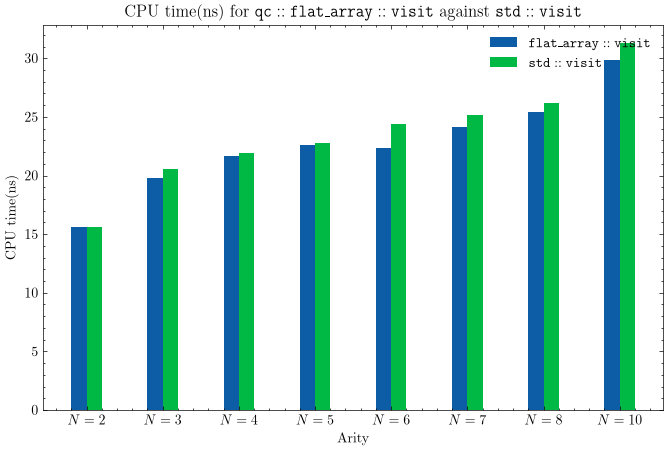

In [4]:
# Plot the benchmarking results
x = np.arange(len(visit_arity))
width = 0.20
categories = [f"$N={arity}$" for arity in visit_arity]

plt.style.use(['science'])
plt.figure(figsize=(8,5))
plt.title('CPU time(ns) for $\\mathtt{qc::flat\\_array::visit}$ against $\\mathtt{std::visit}$')
plt.xlabel('Arity')
plt.ylabel('CPU time(ns)')
plt.bar(x - width/2, flat_array_visit_cpu_times, width, label="$\mathtt{flat\_array::visit}$")
plt.bar(x + width/2, std_visit_cpu_times, width, label="$\mathtt{std::visit}$")
plt.legend(frameon=False, loc='upper right')
plt.xticks(x, categories)
plt.savefig("../benchmarking_results.png", bbox_inches="tight")
plt.show()

In [5]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'bright',
 'cjk-jp-font',
 'cjk-kr-font',
 'cjk-sc-font',
 'cjk-tc-font',
 'classic',
 'dark_background',
 'discrete-rainbow-1',
 'discrete-rainbow-10',
 'discrete-rainbow-11',
 'discrete-rainbow-12',
 'discrete-rainbow-13',
 'discrete-rainbow-14',
 'discrete-rainbow-15',
 'discrete-rainbow-16',
 'discrete-rainbow-17',
 'discrete-rainbow-18',
 'discrete-rainbow-19',
 'discrete-rainbow-2',
 'discrete-rainbow-20',
 'discrete-rainbow-21',
 'discrete-rainbow-22',
 'discrete-rainbow-23',
 'discrete-rainbow-3',
 'discrete-rainbow-4',
 'discrete-rainbow-5',
 'discrete-rainbow-6',
 'discrete-rainbow-7',
 'discrete-rainbow-8',
 'discrete-rainbow-9',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'grid',
 'high-contrast',
 'high-vis',
 'ieee',
 'latex-sans',
 'light',
 'muted',
 'nature',
 'no-latex',
 'notebook',
 'petroff10',
 'petroff6',
 'petroff8',
 'pgf',
 'retro',
 'russian-font',
 'sans'